# Lead Scoring Model v2 — Built on Yelp Open Dataset
**Component: Machine Learning (Lead Scoring)**
Project: AI-Powered Lead Generation & Daily Cold Call Recommendation System — adz4needz

---

### Data source
**Yelp Open Dataset** — `yelp_academic_dataset_business.json`, 150,346 real
businesses with name, location, category, star rating, review count,
attributes, and hours. Licensed for academic/educational use only
(see Yelp's Dataset User Agreement).

### ⚠️ Important — read before using this notebook's results
Yelp does not record cold-call outcomes. There is **no real "converted"
label** anywhere in this data, or anywhere publicly available for this
exact use case, because the adz4needz platform doesn't exist yet.

To demonstrate a working, trainable ML pipeline, this notebook builds a
**documented, rule-based simulated conversion label** — clearly marked
as simulated everywhere it's used — instead of quietly pretending a
proxy is a measured outcome. The rule encodes reasonable, stated sales
assumptions (weak digital presence + decent quality = good outreach
candidate), then adds random noise so the label isn't a deterministic
copy of the input features.

**This means:** the trained model below demonstrates the *methodology*
(feature engineering → imbalance-aware training → evaluation → ranked
daily call list) end-to-end on real business data. It does **not**
demonstrate a model that has learned real-world conversion patterns,
because no real conversion data exists yet. Once adz4needz has actual
call outcomes, retrain this same pipeline on the real `y` label in
place of the simulated one — no other code changes needed.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Load the data

Update `path` below to match where you placed the file in your Drive.

In [3]:
path = "/content/drive/MyDrive/adz/lead_score/yelp_dataset/yelp_academic_dataset_business.json"

df = pd.read_json(path, lines=True)
print(f"Shape: {df.shape}")
df.head()


Shape: (150346, 14)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150346 entries, 0 to 150345
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   business_id   150346 non-null  object 
 1   name          150346 non-null  object 
 2   address       150346 non-null  object 
 3   city          150346 non-null  object 
 4   state         150346 non-null  object 
 5   postal_code   150346 non-null  object 
 6   latitude      150346 non-null  float64
 7   longitude     150346 non-null  float64
 8   stars         150346 non-null  float64
 9   review_count  150346 non-null  int64  
 10  is_open       150346 non-null  int64  
 11  attributes    136602 non-null  object 
 12  categories    150243 non-null  object 
 13  hours         127123 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 16.1+ MB


## 2. Filter to open businesses\n\nClosed businesses aren't cold-call targets — you can't sell to a business that no longer exists.

In [5]:
df = df[df['is_open'] == 1].copy()
print(f"Open businesses: {len(df):,}")


Open businesses: 119,698


Data Cleaning

In [6]:
# ============================================================
# SECTION 2: DATA CLEANING & VALIDATION
# Run this AFTER loading df, BEFORE feature engineering
# ============================================================

print("=" * 60)
print("BEFORE CLEANING")
print("=" * 60)
print(f"Total records: {len(df):,}")

# --- 1. Duplicate business_id check ---
dupe_ids = df['business_id'].duplicated().sum()
print(f"\nDuplicate business_id: {dupe_ids}")
if dupe_ids > 0:
    df = df.drop_duplicates(subset='business_id', keep='first')
    print(f"  -> Dropped. New count: {len(df):,}")

# --- 2. Near-duplicate listings (same name + address) ---
near_dupes = df.duplicated(subset=['name', 'address', 'city', 'state']).sum()
print(f"Near-duplicate listings (same name+address): {near_dupes}")
if near_dupes > 0:
    df = df.drop_duplicates(subset=['name', 'address', 'city', 'state'], keep='first')
    print(f"  -> Dropped. New count: {len(df):,}")

# --- 3. Invalid star ratings ---
invalid_stars = df[(df['stars'] < 1) | (df['stars'] > 5)]
print(f"\nInvalid star ratings (outside 1-5): {len(invalid_stars)}")
df = df[(df['stars'] >= 1) & (df['stars'] <= 5)]

# --- 4. Invalid review counts ---
invalid_reviews = df[df['review_count'] < 0]
print(f"Negative review counts: {len(invalid_reviews)}")
df = df[df['review_count'] >= 0]

# Suspicious: high rating with 0 reviews (shouldn't be possible on Yelp)
suspicious = df[(df['review_count'] == 0) & (df['stars'] > 0)]
print(f"Zero reviews but has a star rating (flag, not dropped): {len(suspicious)}")

# --- 5. Blank/whitespace-only name or city (nulls already handled, check blanks) ---
blank_name = df['name'].astype(str).str.strip().eq('').sum()
blank_city = df['city'].astype(str).str.strip().eq('').sum()
print(f"\nBlank name: {blank_name}   Blank city: {blank_city}")
df = df[df['name'].astype(str).str.strip() != '']
df = df[df['city'].astype(str).str.strip() != '']

# --- 6. State code sanity check (Yelp includes non-US regions) ---
print(f"\nUnique state codes: {df['state'].nunique()}")
print(df['state'].value_counts().head(20))
# Uncomment to restrict to US states only:
# us_states = {'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
#              'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
#              'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
#              'VA','WA','WV','WI','WY'}
# before = len(df)
# df = df[df['state'].isin(us_states)]
# print(f"Filtered to US states only: dropped {before - len(df):,} rows")

# --- 7. Postal code sanity check ---
df['postal_code'] = df['postal_code'].astype(str).str.strip()
malformed_zip = df[~df['postal_code'].str.match(r'^\d{3,10}$', na=False)]
print(f"\nMalformed postal codes: {len(malformed_zip)}")

# --- 8. Clean up categories text (whitespace/casing consistency) ---
df['categories'] = df['categories'].str.strip()

# --- 9. Fix nested/stringified values inside attributes ---
# Some Yelp attributes are stringified dicts, e.g. "{'garage': False}" instead
# of a clean True/False. Flatten or ignore these safely rather than letting
# them silently break the digital_signal_count logic later.
def clean_attributes(attrs):
    if not isinstance(attrs, dict):
        return {}
    cleaned = {}
    for k, v in attrs.items():
        if isinstance(v, str) and v.startswith('{'):
            continue  # skip nested dict-like attributes for now (e.g. BusinessParking)
        cleaned[k] = v
    return cleaned

df['attributes'] = df['attributes'].apply(clean_attributes)

print("\n" + "=" * 60)
print("AFTER CLEANING")
print("=" * 60)
print(f"Total records: {len(df):,}")
print(f"Nulls remaining:\n{df.isnull().sum()}")

BEFORE CLEANING
Total records: 119,698

Duplicate business_id: 0
Near-duplicate listings (same name+address): 62
  -> Dropped. New count: 119,636

Invalid star ratings (outside 1-5): 0
Negative review counts: 0
Zero reviews but has a star rating (flag, not dropped): 0

Blank name: 0   Blank city: 0

Unique state codes: 24
state
PA    26275
FL    21529
TN     9594
IN     8940
MO     8356
AZ     8106
LA     7672
NJ     7028
NV     6272
AB     4346
CA     4064
ID     3781
DE     1893
IL     1765
TX        4
WA        2
MA        2
HI        1
CO        1
UT        1
Name: count, dtype: int64

Malformed postal codes: 4370

AFTER CLEANING
Total records: 119,636
Nulls remaining:
business_id         0
name                0
address             0
city                0
state               0
postal_code         0
latitude            0
longitude           0
stars               0
review_count        0
is_open             0
attributes          0
categories         95
hours           16080
dtype: int

## 3. Feature engineering

Mapping onto the project deck's Feature Engineering slide:
- **Website Presence / Digital maturity** → approximated via listed hours +
  count of digital/operational attributes (Yelp has no `website` field)
- **Review Count & Rating** → `review_count` (log-scaled, heavy-tailed) and `stars`
- **Social Activity** → not available in this dataset (flagged as a gap below)
- **Industry Type** → `categories` (primary category extracted)

In [7]:
# --- Digital / operational maturity signals ---
digital_signal_attrs = [
    'BusinessAcceptsCreditCards', 'WiFi', 'RestaurantsDelivery',
    'RestaurantsTakeOut', 'RestaurantsReservations', 'ByAppointmentOnly',
    'OutdoorSeating', 'RestaurantsGoodForGroups', 'BusinessAcceptsBitcoin',
    'WheelchairAccessible'
]

def count_digital_signals(attrs):
    if not isinstance(attrs, dict):
        return 0
    return sum(
        1 for k in digital_signal_attrs
        if k in attrs and str(attrs[k]).lower() not in ('false', 'none', 'nan')
    )

df['digital_signal_count'] = df['attributes'].apply(count_digital_signals)
df['has_hours'] = df['hours'].notna().astype(int)
df['num_days_open'] = df['hours'].apply(lambda h: len(h) if isinstance(h, dict) else 0)
df['num_attributes'] = df['attributes'].apply(lambda x: len(x) if isinstance(x, dict) else 0)

df['digital_maturity_score'] = (
    0.4 * df['has_hours'] +
    0.3 * (df['num_days_open'] / 7) +
    0.3 * (df['digital_signal_count'] / len(digital_signal_attrs))
).round(3)

# --- Popularity & satisfaction ---
df['review_count_log'] = np.log1p(df['review_count'])
df['popularity_score'] = (df['review_count_log'] / df['review_count_log'].max()).round(3)
df['satisfaction_score'] = (df['stars'] / 5.0).round(3)

# --- Industry ---
df['primary_category'] = df['categories'].fillna('Unknown').str.split(',').str[0].str.strip()
top_categories = df['primary_category'].value_counts().head(20).index
df['category_grouped'] = df['primary_category'].where(df['primary_category'].isin(top_categories), 'Other')

print(f"Top categories:\n{df['category_grouped'].value_counts().head(10)}")


Top categories:
category_grouped
Other                        68142
Restaurants                   9962
Food                          4944
Shopping                      4461
Beauty & Spas                 3778
Home Services                 3522
Automotive                    3158
Health & Medical              2850
Local Services                2389
Event Planning & Services     1729
Name: count, dtype: int64


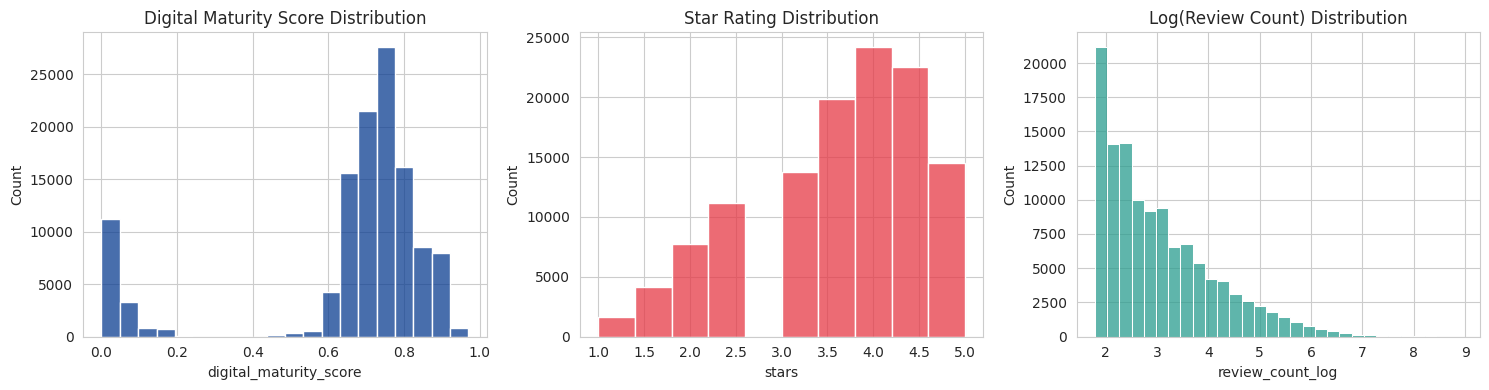

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
sns.histplot(df['digital_maturity_score'], bins=20, ax=axes[0], color="#0b3d91")
axes[0].set_title("Digital Maturity Score Distribution")

sns.histplot(df['stars'], bins=10, ax=axes[1], color="#e63946")
axes[1].set_title("Star Rating Distribution")

sns.histplot(df['review_count_log'], bins=30, ax=axes[2], color="#2a9d8f")
axes[2].set_title("Log(Review Count) Distribution")
plt.tight_layout()
plt.show()


## 4. Build the simulated conversion label (documented assumptions)

**These weights are stated sales assumptions, not learned from data:**
1. Businesses with **weaker digital maturity** are more likely to need/want
   the kind of service being pitched (higher simulated propensity).
2. Businesses with **decent-to-good ratings** (3.5–4.5) are attractive
   customers — good enough to be a safe bet, not so perfect they don't
   need help. Modeled as a bell curve peaking around 4.0 stars.
3. Businesses with a **moderate review count** (established, but not a
   huge chain) are more reachable/relevant than brand-new or already-huge
   businesses. Also modeled as a bell curve.
4. Random noise is added so the label isn't a perfect deterministic
   function of the inputs — real conversion always has an unexplained
   component (timing, who picks up the phone, mood, competing offers).

In [9]:
rng = np.random.default_rng(RANDOM_STATE)

# Assumption 1: weaker digital maturity -> higher propensity
a1 = (1 - df['digital_maturity_score'])

# Assumption 2: rating sweet spot around 4.0 stars
a2 = np.exp(-((df['stars'] - 4.0) ** 2) / (2 * 0.6 ** 2))

# Assumption 3: review count sweet spot (log scale), around the 40th percentile
target_log_reviews = df['review_count_log'].quantile(0.4)
a3 = np.exp(-((df['review_count_log'] - target_log_reviews) ** 2) / (2 * 1.2 ** 2))

# Combine into an underlying propensity, then squash to (0,1)
linear_score = 1.8 * a1 + 1.6 * a2 + 1.2 * a3 - 2.0
propensity = 1 / (1 + np.exp(-linear_score))

# Add noise: real-world outcomes are never a clean function of features
noise = rng.normal(0, 0.15, size=len(df))
noisy_propensity = np.clip(propensity + noise, 0.01, 0.99)

# Sample the actual binary outcome stochastically -- this is the label
df['converted_SIMULATED'] = rng.binomial(1, noisy_propensity)

print(f"Simulated conversion rate: {df['converted_SIMULATED'].mean():.1%}")
print("(This is a designed assumption, not a measured business outcome.)")


Simulated conversion rate: 57.2%
(This is a designed assumption, not a measured business outcome.)


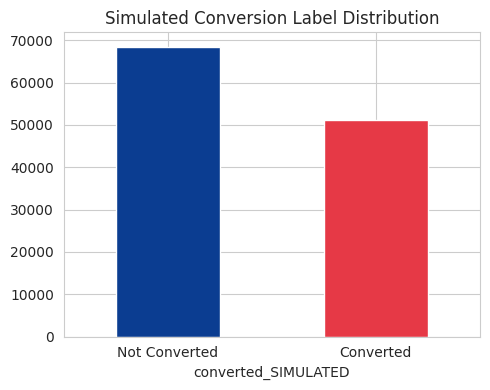

In [10]:
plt.figure(figsize=(5,4))
df['converted_SIMULATED'].value_counts().plot(kind='bar', color=["#0b3d91","#e63946"])
plt.title("Simulated Conversion Label Distribution")
plt.xticks([0,1], ["Not Converted","Converted"], rotation=0)
plt.tight_layout()
plt.show()


## 5. Train / test split and preprocessing

In [11]:
feature_cols_num = [
    'digital_maturity_score', 'has_hours', 'num_days_open', 'digital_signal_count',
    'num_attributes', 'review_count_log', 'stars', 'satisfaction_score', 'popularity_score'
]
feature_cols_cat = ['category_grouped', 'state']

X = df[feature_cols_num + feature_cols_cat]
y = df['converted_SIMULATED']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
    ("num", StandardScaler(), feature_cols_num),
])

print(f"Train: {X_train.shape[0]:,}   Test: {X_test.shape[0]:,}")


Train: 95,708   Test: 23,928


## 6. Train and compare models

In [12]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "random_forest": RandomForestClassifier(
        n_estimators=300, max_depth=10, class_weight="balanced",
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "xgboost": XGBClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    ),
}

results = {}
fitted_pipelines = {}

for name, clf in models.items():
    pipe = Pipeline([("prep", preprocessor), ("clf", clf)])
    pipe.fit(X_train, y_train)
    probs = pipe.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.5).astype(int)

    auc = roc_auc_score(y_test, probs)
    ap = average_precision_score(y_test, probs)
    report = classification_report(y_test, preds, output_dict=True)

    results[name] = {
        "roc_auc": auc,
        "avg_precision": ap,
        "precision_converted": report["1"]["precision"],
        "recall_converted": report["1"]["recall"],
        "f1_converted": report["1"]["f1-score"],
    }
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
results_df


,roc_auc,avg_precision,precision_converted,recall_converted,f1_converted
xgboost,0.693359,0.742890,0.717388,0.610502,0.659643
random_forest,0.690543,0.739082,0.717995,0.603783,0.655955
logistic_regression,0.649806,0.699410,0.682116,0.578294,0.625929


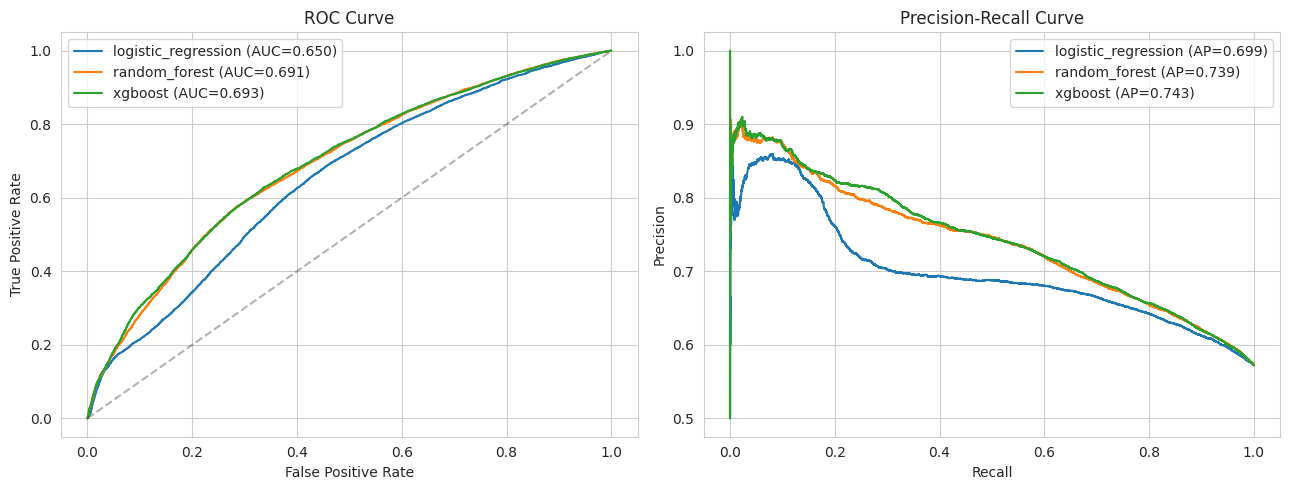

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, pipe in fitted_pipelines.items():
    probs = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={results[name]['roc_auc']:.3f})")
    prec, rec, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(rec, prec, label=f"{name} (AP={results[name]['avg_precision']:.3f})")

axes[0].plot([0,1],[0,1],'k--', alpha=0.3)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve"); axes[0].legend()
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve"); axes[1].legend()
plt.tight_layout()
plt.show()


## 7. Best model, confusion matrix, classification report

Best model: xgboost  (ROC-AUC=0.693)
               precision    recall  f1-score   support

Not Converted       0.57      0.68      0.62     10236
    Converted       0.72      0.61      0.66     13692

     accuracy                           0.64     23928
    macro avg       0.64      0.64      0.64     23928
 weighted avg       0.65      0.64      0.64     23928



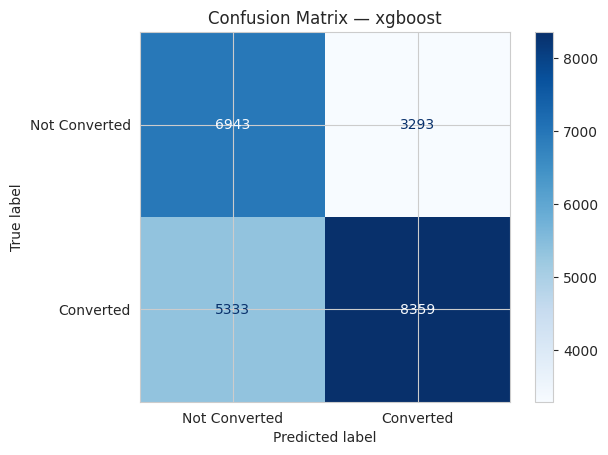

In [14]:
best_name = results_df.index[0]
best_pipeline = fitted_pipelines[best_name]
print(f"Best model: {best_name}  (ROC-AUC={results[best_name]['roc_auc']:.3f})")

probs = best_pipeline.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)
print(classification_report(y_test, preds, target_names=["Not Converted","Converted"]))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=["Not Converted","Converted"]).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_name}")
plt.show()


## 8. Feature importance

Since the label is simulated from `digital_maturity_score`, `stars`, and
`review_count_log` by design, we'd *expect* those to dominate here — this
plot is really a sanity check that the model recovered the intended
pattern, not a discovery about real-world sales behavior.

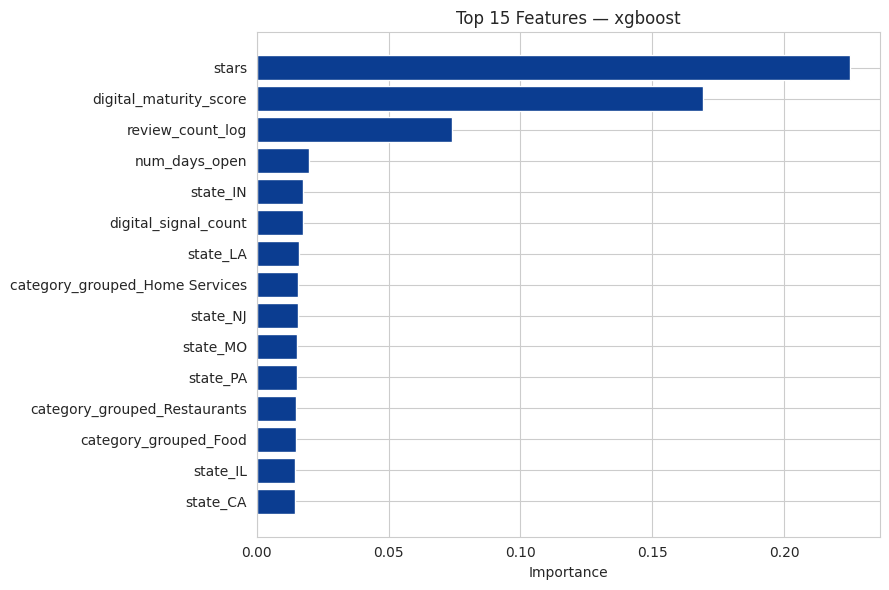

,feature,importance
49,stars,0.225111
43,digital_maturity_score,0.169352
48,review_count_log,0.073842
45,num_days_open,0.019925
29,state_IN,0.017539
46,digital_signal_count,0.017337
30,state_LA,0.015911
11,category_grouped_Home Services,0.015732
34,state_NJ,0.015576
33,state_MO,0.015402


In [15]:
clf = best_pipeline.named_steps["clf"]
prep = best_pipeline.named_steps["prep"]
feature_names = prep.get_feature_names_out()

if hasattr(clf, "feature_importances_"):
    importances = clf.feature_importances_
else:
    importances = np.abs(clf.coef_[0])

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df["feature"] = imp_df["feature"].str.replace("cat__","").str.replace("num__","")
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9,6))
plt.barh(imp_df["feature"][::-1], imp_df["importance"][::-1], color="#0b3d91")
plt.xlabel("Importance")
plt.title(f"Top 15 Features — {best_name}")
plt.tight_layout()
plt.savefig("feature_importance_yelp.png", dpi=150)
plt.show()
imp_df


## 9. Save the trained model

In [16]:
joblib.dump(best_pipeline, "lead_scoring_model_yelp.joblib")
with open("model_comparison_yelp.json","w") as f:
    json.dump(results, f, indent=2)
print("Saved lead_scoring_model_yelp.joblib")


Saved lead_scoring_model_yelp.joblib


## 10. Generate today's ranked call list

Matches the deck's **Daily Call List** module: score every open business,
rank by predicted conversion probability, assign a priority tier.

In [17]:
df['conversion_score'] = best_pipeline.predict_proba(X)[:, 1]

def priority_tier(score):
    if score >= 0.6: return "High"
    elif score >= 0.35: return "Medium"
    return "Low"

df['priority'] = df['conversion_score'].apply(priority_tier)

today_pool = df.sample(n=500, random_state=7).copy()

daily_call_list = today_pool.sort_values('conversion_score', ascending=False)[
    ['business_id','name','city','state','category_grouped','stars',
     'review_count','digital_maturity_score','conversion_score','priority']
].reset_index(drop=True)

daily_call_list['conversion_score'] = (daily_call_list['conversion_score'] * 100).round(1)
daily_call_list.rename(columns={'conversion_score':'conversion_score_pct'}, inplace=True)
daily_call_list.to_csv("daily_call_list_yelp.csv", index=False)

print("Today's top 10 recommended calls:")
daily_call_list.head(10)


Today's top 10 recommended calls:


,business_id,name,city,state,category_grouped,stars,review_count,digital_maturity_score,conversion_score_pct,priority
0,U-jlsqgnVkYycr2N2YYEcg,Penrod Arts Fair,Indianapolis,IN,Other,4.0,16,0.00,87.699997,High
1,c2zfvdiLqExtrHGRJahmTQ,Tucson Roller Derby,Tucson,AZ,Other,4.0,12,0.00,87.300003,High
2,kyosRyLvRHOWAIvfV4s7cw,Sparks Marina Park,Sparks,NV,Active Life,4.0,100,0.00,87.300003,High
3,ahxnXXeQcAkQ5z6HCm_r0Q,Burger Showdown,Tampa,FL,Other,4.0,16,0.00,87.199997,High
4,iKk6A3JiiMRDpPXw_niCBg,Palmer Park,New Orleans,LA,Active Life,4.0,13,0.00,87.199997,High
5,uRtsuwico2-3egGQBNs-Zw,ForCare Medical Center,Tampa,FL,Beauty & Spas,4.0,31,0.09,86.900002,High
6,lJKN4qB4eIDp3tJ9ocS2Jw,DJ Connection,Carmel,IN,Other,4.0,5,0.00,86.699997,High
7,_h4b7BcDXWnhm4RZX6I4dg,Riviera Pizza,Medford,NJ,Sandwiches,4.0,19,0.09,86.199997,High
8,DV08ZJKq_hPS_6Q8GKt0pg,Philly Fry Truck,Philadelphia,PA,Other,4.0,13,0.09,85.699997,High
9,jEZqOdf6ckeeUy9jWJx6iw,Platt's Farm Market,Clarksboro,NJ,Other,4.0,18,0.03,85.599998,High


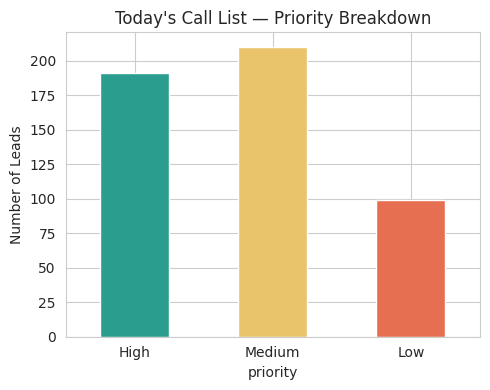

In [18]:
plt.figure(figsize=(5,4))
daily_call_list['priority'].value_counts().reindex(['High','Medium','Low']).plot(
    kind='bar', color=["#2a9d8f","#e9c46a","#e76f51"]
)
plt.title("Today's Call List — Priority Breakdown")
plt.ylabel("Number of Leads")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 11. Summary — what this notebook proves, and what it doesn't

**What's real:** 150K+ real Yelp businesses, real ratings, real review
counts, real categories, real operational attributes.

**What's simulated:** the `converted_SIMULATED` label. There is no real
conversion data available for adz4needz yet, so this notebook cannot and
does not claim to predict real-world cold-call success. It demonstrates
that the full pipeline — feature engineering on real business data,
imbalance-aware model training, evaluation, and a ranked daily call list
— works end-to-end and is ready to be pointed at real labels the moment
adz4needz's Call Tracking module starts logging actual outcomes
(Interested / Not Interested / Converted / Not Converted, per the deck's
Call Tracking slide).

**Recommended framing for your presentation:** show this notebook as the
engineering proof-of-concept, and be upfront that the label is a stated,
documented simulation pending real usage data — that's a stronger,
more credible story than presenting simulated results as measured
performance.

In [19]:
from google.colab import files

# Download the trained model (for backend)
files.download("lead_scoring_model_yelp.joblib")

# Download the model comparison metrics (for backend/docs)
files.download("model_comparison_yelp.json")

# Download the daily call list sample (for frontend to build against)
files.download("daily_call_list_yelp.csv")

# Download the feature importance chart (useful for your report/slides too)
files.download("feature_importance_yelp.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>